# BERTopic - Vibecoding Tweet Topic Modeling

Notebook ini menjalankan BERTopic pada dataset tweet vibecoding yang sama dengan FASTopic
(`preprocessed_new_vibe_coding_tweets.csv`) supaya hasilnya bisa dibandingkan apple-to-apple.

**Pipeline BERTopic:** sentence embedding (MiniLM) -> UMAP dim reduction -> HDBSCAN clustering ->
c-TF-IDF untuk ekstraksi topic words. Berbeda dengan FASTopic (model probabilistik dengan
transport-plan loss), BERTopic adalah pipeline diskrit berbasis clustering.

In [1]:
!pip install topmost
!pip install bertopic

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.3/79.3 kB 4.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 79.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.9/9.9 MB 109.2 MB/s eta 0:00:00
  Attempting uninstall: plotly
    Found existing installation: plotly 5.24.1
    Uninstalling plotly-5.24.1:
      Successfully uninstalled plotly-5.24.1
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.7/154.7 kB 7.8 MB/s eta 0:00:00


In [2]:
import pandas as pd
import numpy as np
import random
import torch
from bertopic import BERTopic

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

# Dataset SAMA persis dengan FASTopic notebook -> hasil dapat dibandingkan langsung.
df_preprocessed = pd.read_csv(r"/content/preprocessed_tweets.csv")
print(f"Total dokumen: {len(df_preprocessed)}")
df_preprocessed.head()

Total dokumen: 35159


,full_text,image_url,created_at,tweet_url,id_str
0,saw guy coding today tab chatgpt gemini claude...,NaN,April 2025,https://x.com/Yuchenj_UW/status/19165377865194...,1916537786519425124
1,imagine way thinking edge taste strategy could...,https://pbs.twimg.com/amplify_video_thumb/1919...,May 2025,https://x.com/FractionAI_xyz/status/1919796178...,1919796178033483801
2,guy one kenya best brains know introducing joh...,https://pbs.twimg.com/media/G1wuNGRXAAE8RBi.jpg,September 2025,https://x.com/onjolo_kenya/status/197150154911...,1971501549110141021
3,know funny people hear pope leo xiv math degre...,https://pbs.twimg.com/media/GqyT_bsXQAAzDiI.jpg,May 2025,https://x.com/SecretFire79/status/192207386337...,1922073863376011765
4,people today discouraging others learning prog...,NaN,March 2025,https://x.com/AndrewYNg/status/190021911682210...,1900219116822102116


In [3]:
docs = df_preprocessed['full_text'].fillna('').tolist()
images = df_preprocessed['image_url'].tolist()
timestamps = df_preprocessed['created_at'].tolist()
ids = df_preprocessed['id_str'].tolist()
tweet_urls = df_preprocessed['tweet_url'].tolist()

for i in range(len(images)):
    if pd.isna(images[i]):
        images[i] = None

# JANGAN shuffle docs supaya index assignment tetap traceable ke dataframe asli.
print(f"Sample doc[0]: {docs[0][:120]}")

Sample doc[0]: saw guy coding today tab chatgpt gemini claude grok deepseek asked every exact question patiently waited pasted response


## Evaluation Setup

Memakai `topmost.Preprocess` HANYA untuk membangun reference corpus + vocabulary yang
identik dengan FASTopic & Top2Vec. Ini penting supaya skor coherence bisa dibandingkan
secara fair antar model (gensim `CoherenceModel` butuh dictionary yang konsisten).

Tiga metric yang dipakai:
- **C_v** — PMI berbasis sliding window + cosine similarity. Range ~0-1. Metric default di literatur BERTopic.
- **C_npmi** — Normalized PMI. Range ~[-1, 1] (~0.05-0.20 untuk tweet). Dipakai di paper FASTopic.
- **Topic diversity** — proporsi kata unik di seluruh top words antar topik. Range 0-1.

In [4]:
from topmost import Preprocess
from topmost.eva import _coherence, _diversity

# Stopwords config IDENTIK dengan FASTopic notebook.
domain_stopwords = ["vibecoding", "vibecode", "vibecoded", "vibe", "vibes"]
generic_stopwords = [
    "code", "coding"
]

shared_preprocess = Preprocess(
    stopwords=domain_stopwords + generic_stopwords,
)

prep_result = shared_preprocess.preprocess(docs)
ref_corpus = prep_result['train_texts']
ref_vocab = prep_result['vocab']
print(f"Reference corpus: {len(ref_corpus)} docs | vocab: {len(ref_vocab)} terms")

parsing texts: 100%|██████████| 35159/35159 [00:04<00:00, 8233.58it/s] 
2026-06-23 05:24:39,791 - TopMost - Real vocab size: 28664
2026-06-23 05:24:39,802 - TopMost - Real training size: 35159 	 avg length: 16.129


Reference corpus: 35159 docs | vocab: 28664 terms


In [5]:
def evaluate_topics(top_words, ref_corpus, ref_vocab, topn=10):
    """Hitung c_v coherence, c_npmi coherence, dan topic diversity.

    top_words: List[str] di mana tiap string = top words satu topik dipisah spasi.
    """
    truncated = [' '.join(tw.split()[:topn]) for tw in top_words]
    cv = _coherence(ref_corpus, ref_vocab, truncated, coherence_type='c_v', topn=topn)
    npmi = _coherence(ref_corpus, ref_vocab, truncated, coherence_type='c_npmi', topn=topn)
    td = _diversity(truncated)
    return {'c_v': cv, 'c_npmi': npmi, 'diversity': td}


def bertopic_top_words(topic_model, topn=15):
    """Ekstrak top words per topic dari BERTopic, exclude outlier topic (-1).
    Output: List[str] dengan format yang sama dengan FASTopic top_words.
    """
    topics = topic_model.get_topics()
    sorted_ids = sorted([tid for tid in topics.keys() if tid != -1])
    return [' '.join([w for w, _ in topics[tid][:topn]]) for tid in sorted_ids]

## BERTopic Config Rationale

- **Embedding model**: `all-MiniLM-L6-v2` -> SAMA dengan FASTopic untuk fairness.
- **`min_topic_size`=50**: Default 10 menghasilkan ratusan micro-topic pada 16k tweets.
  50 lebih sehat untuk corpus segini (mirip threshold yang dipakai paper BERTopic untuk Twitter).
- **`vectorizer_model` shared vocab**: CountVectorizer dipaksa pakai `ref_vocab` yang sama
  dengan FASTopic supaya c-TF-IDF beroperasi di vocabulary yang identik. Ini memastikan
  `evaluate_topics()` jalan dengan dictionary yang konsisten.
- **Pre-compute embeddings sekali**: kita encode semua dokumen sekali lalu reuse untuk tiap K
  di sweep -> hemat ~30 detik per K.

In [6]:
from sentence_transformers import SentenceTransformer
from sklearn.feature_extraction.text import CountVectorizer

EMBED_MODEL_NAME = "sentence-transformers/all-MiniLM-L6-v2"

# Pre-compute embeddings SEKALI -> reuse di setiap fit BERTopic untuk hemat waktu.
embed_model = SentenceTransformer(EMBED_MODEL_NAME, device="cuda" if torch.cuda.is_available() else "cpu")
doc_embeddings = embed_model.encode(docs, show_progress_bar=True, batch_size=64)
print(f"Embeddings shape: {doc_embeddings.shape}")

# Vectorizer dengan vocab yang sama dengan FASTopic ref_vocab.
shared_vectorizer = CountVectorizer(vocabulary=ref_vocab)

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/10.5k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/612 [00:00<?, ?B/s]

...

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Batches:   0%|          | 0/550 [00:00<?, ?it/s]

Embeddings shape: (35159, 384)


## K-Sweep via `nr_topics`

BERTopic awalnya menghasilkan banyak topik dari HDBSCAN, lalu `nr_topics=K` akan otomatis
menggabungkan topik termirip sampai jumlahnya = K. Ini setara dengan K-sweep di FASTopic.

Catatan: BERTopic kadang menghasilkan jumlah topik **lebih kecil** dari target K kalau
HDBSCAN tidak menemukan cukup cluster valid. Karena itu kita track `K_target` (yang diminta)
dan `K_actual` (yang dihasilkan).

In [7]:
K_VALUES = [8, 12, 15, 20, 25]
sweep_results = []

for k in K_VALUES:
    print(f"\n=== Training BERTopic with nr_topics={k} ===")
    np.random.seed(SEED)
    torch.manual_seed(SEED)

    bt = BERTopic(
        embedding_model=embed_model,
        vectorizer_model=shared_vectorizer,
        nr_topics=k,
        calculate_probabilities=False,
        verbose=False,
    )
    bt.fit(docs, embeddings=doc_embeddings)
    tw = bertopic_top_words(bt, topn=10)
    metrics = evaluate_topics(tw, ref_corpus, ref_vocab, topn=10)
    metrics['K_target'] = k
    metrics['K_actual'] = len(tw)
    sweep_results.append(metrics)
    print(f"  target={k} actual={len(tw)}  c_v={metrics['c_v']:.4f}  c_npmi={metrics['c_npmi']:.4f}  diversity={metrics['diversity']:.4f}")
    del bt

sweep_df = pd.DataFrame(sweep_results)[['K_target', 'K_actual', 'c_v', 'c_npmi', 'diversity']]
sweep_df['combined'] = ((sweep_df['c_v'] + (sweep_df['c_npmi'] + 1) / 2) / 2) * sweep_df['diversity']
sweep_df.sort_values('combined', ascending=False)


=== Training BERTopic with nr_topics=8 ===


/usr/local/lib/python3.12/dist-packages/bertopic/vectorizers/_ctfidf.py:82: RuntimeWarning: divide by zero encountered in divide
  idf = np.log((avg_nr_samples / df) + 1)
/usr/local/lib/python3.12/dist-packages/bertopic/vectorizers/_ctfidf.py:82: RuntimeWarning: divide by zero encountered in divide
  idf = np.log((avg_nr_samples / df) + 1)


  target=8 actual=7  c_v=0.4841  c_npmi=0.0214  diversity=0.9286

=== Training BERTopic with nr_topics=12 ===


/usr/local/lib/python3.12/dist-packages/bertopic/vectorizers/_ctfidf.py:82: RuntimeWarning: divide by zero encountered in divide
  idf = np.log((avg_nr_samples / df) + 1)
/usr/local/lib/python3.12/dist-packages/bertopic/vectorizers/_ctfidf.py:82: RuntimeWarning: divide by zero encountered in divide
  idf = np.log((avg_nr_samples / df) + 1)


  target=12 actual=11  c_v=0.5050  c_npmi=0.0279  diversity=0.9364

=== Training BERTopic with nr_topics=15 ===


...

/usr/local/lib/python3.12/dist-packages/bertopic/vectorizers/_ctfidf.py:82: RuntimeWarning: divide by zero encountered in divide
  idf = np.log((avg_nr_samples / df) + 1)
/usr/local/lib/python3.12/dist-packages/bertopic/vectorizers/_ctfidf.py:82: RuntimeWarning: divide by zero encountered in divide
  idf = np.log((avg_nr_samples / df) + 1)


  target=20 actual=19  c_v=0.5584  c_npmi=0.0720  diversity=0.9105

=== Training BERTopic with nr_topics=25 ===


/usr/local/lib/python3.12/dist-packages/bertopic/vectorizers/_ctfidf.py:82: RuntimeWarning: divide by zero encountered in divide
  idf = np.log((avg_nr_samples / df) + 1)
/usr/local/lib/python3.12/dist-packages/bertopic/vectorizers/_ctfidf.py:82: RuntimeWarning: divide by zero encountered in divide
  idf = np.log((avg_nr_samples / df) + 1)


  target=25 actual=24  c_v=0.5137  c_npmi=0.0341  diversity=0.8667


,K_target,K_actual,c_v,c_npmi,diversity,combined
3,20,19,0.558422,0.072038,0.910526,0.498259
1,12,11,0.505048,0.027896,0.936364,0.477075
0,8,7,0.484089,0.021446,0.928571,0.461877
4,25,24,0.513696,0.034061,0.866667,0.446648
2,15,14,0.434526,-0.021194,0.928571,0.428967


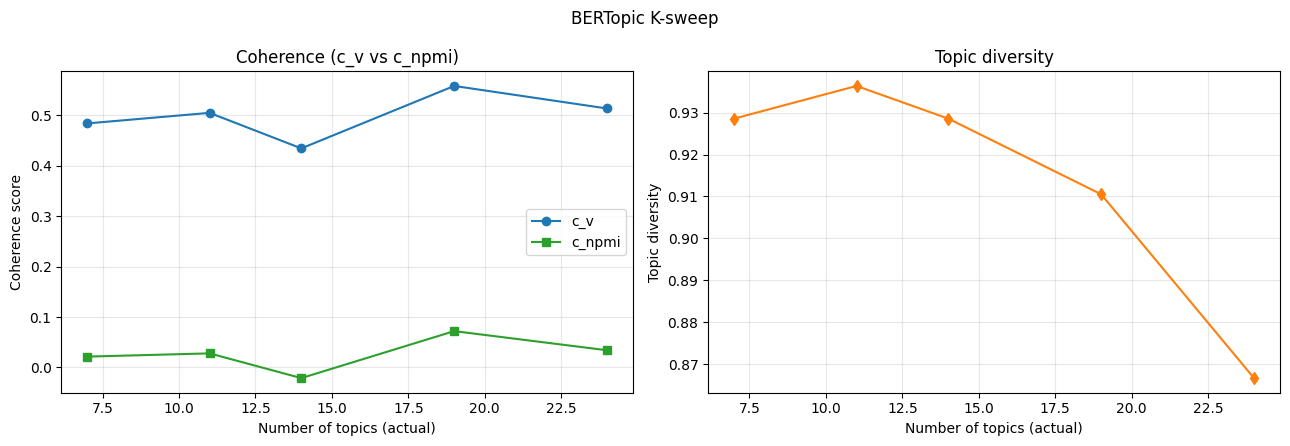


Rekomendasi nr_topics (max combined score): 20
Override manual jika perlu dengan mengubah NUM_TOPICS di cell training di bawah.


In [8]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

ax1 = axes[0]
ax1.plot(sweep_df['K_actual'], sweep_df['c_v'], 'o-', color='tab:blue', label='c_v')
ax1.plot(sweep_df['K_actual'], sweep_df['c_npmi'], 's-', color='tab:green', label='c_npmi')
ax1.set_xlabel('Number of topics (actual)')
ax1.set_ylabel('Coherence score')
ax1.set_title('Coherence (c_v vs c_npmi)')
ax1.legend()
ax1.grid(alpha=0.3)

ax2 = axes[1]
ax2.plot(sweep_df['K_actual'], sweep_df['diversity'], 'd-', color='tab:orange')
ax2.set_xlabel('Number of topics (actual)')
ax2.set_ylabel('Topic diversity')
ax2.set_title('Topic diversity')
ax2.grid(alpha=0.3)

plt.suptitle('BERTopic K-sweep')
fig.tight_layout()
plt.show()

best_idx = sweep_df['combined'].idxmax()
best_k = int(sweep_df.loc[best_idx, 'K_target'])
print(f"\nRekomendasi nr_topics (max combined score): {best_k}")
print("Override manual jika perlu dengan mengubah NUM_TOPICS di cell training di bawah.")

## Final Model

In [29]:
NUM_TOPICS = 25
print(f"Training final BERTopic with nr_topics={NUM_TOPICS}")

np.random.seed(SEED)
torch.manual_seed(SEED)

model = BERTopic(
    embedding_model=embed_model,
    vectorizer_model=shared_vectorizer,
    nr_topics=NUM_TOPICS,
    calculate_probabilities=True,
    verbose=True,
)
topics, probs = model.fit_transform(docs, embeddings=doc_embeddings)

top_words = bertopic_top_words(model, topn=15)
final_metrics = evaluate_topics(top_words, ref_corpus, ref_vocab, topn=10)
print(
    f"\nFinal BERTopic | target K={NUM_TOPICS}  actual={len(top_words)}"
    f"  c_v={final_metrics['c_v']:.4f}"
    f"  c_npmi={final_metrics['c_npmi']:.4f}"
    f"  diversity={final_metrics['diversity']:.4f}\n"
)
for i, tw in enumerate(top_words):
    print(f"Topic {i}: {tw}")

bertopic_metrics = {**final_metrics, 'model': 'BERTopic', 'K': len(top_words)}

2026-06-23 05:41:20,504 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm


Training final BERTopic with nr_topics=25


2026-06-23 05:41:52,008 - BERTopic - Dimensionality - Completed ✓
2026-06-23 05:41:52,010 - BERTopic - Cluster - Start clustering the reduced embeddings
2026-06-23 05:43:23,849 - BERTopic - Cluster - Completed ✓
2026-06-23 05:43:23,850 - BERTopic - Representation - Extracting topics using c-TF-IDF for topic reduction.
/usr/local/lib/python3.12/dist-packages/bertopic/vectorizers/_ctfidf.py:82: RuntimeWarning: divide by zero encountered in divide
  idf = np.log((avg_nr_samples / df) + 1)
2026-06-23 05:43:24,504 - BERTopic - Representation - Completed ✓
2026-06-23 05:43:24,506 - BERTopic - Topic reduction - Reducing number of topics
2026-06-23 05:43:24,560 - BERTopic - Representation - Fine-tuning topics using representation models.
/usr/local/lib/python3.12/dist-packages/bertopic/vectorizers/_ctfidf.py:82: RuntimeWarning: divide by zero encountered in divide
  idf = np.log((avg_nr_samples / df) + 1)
2026-06-23 05:43:25,049 - BERTopic - Representation - Completed ✓
2026-06-23 05:43:25,055


Final BERTopic | target K=25  actual=24  c_v=0.5093  c_npmi=0.0295  diversity=0.9042

Topic 0: app like apps game one new claude get build using
Topic 1: llm agents cursor agent build like create without using tools
Topic 2: openai meme token launch one memecoin memecoins company building troll
Topic 3: blockchain data decentralized crypto storage glint walrus web layer gensyn
Topic 4: python machine learning programming data beginners libraries kindle link guide
Topic 5: gpt grok openai model models reasoning openrouter xai new instruction
Topic 6: models livecodebench reasoning deepseek benchmark benchmarks pro intelligence model livecodebenchpro
Topic 7: neural networks deep learning network reinforcement lstm recurrent series quantum
Topic 8: doctors healthcare medical practice health practices care doctor services ehr
Topic 9: books free ebook science data courses machine read learning top
Topic 10: musk elon war africa ukraine people nations grok india russian
Topic 11: apple ca

In [30]:
new_topics = model.reduce_outliers(docs, topics)

100%|██████████| 21/21 [00:03<00:00,  6.32it/s]


In [31]:
model.update_topics(docs, topics=new_topics, vectorizer_model=shared_vectorizer)

2026-06-23 05:43:52,869 - BERTopic - WARNING: Using a custom list of topic assignments may lead to errors if topic reduction techniques are used afterwards. Make sure that manually assigning topics is the last step in the pipeline.Note that topic embeddings will also be created through weightedc-TF-IDF embeddings instead of centroid embeddings.
/usr/local/lib/python3.12/dist-packages/bertopic/vectorizers/_ctfidf.py:82: RuntimeWarning: divide by zero encountered in divide
  idf = np.log((avg_nr_samples / df) + 1)


In [32]:
# Topic info table dari built-in BERTopic
topic_info = model.get_topic_info()
topic_info.head(19)

,Topic,Count,Name,Representation,Representative_Docs
0,-1,2,-1_brainfm_jukedeck_vibeinvesting_vibemanaging,"[brainfm, jukedeck, vibeinvesting, vibemanagin...",[steps learn fast new year featuring best guid...
1,0,15667,0_app_like_one_new,"[app, like, one, new, get, apps, time, build, ...",[one favorite new feature lovable security che...
2,1,9885,1_agents_llm_build_agent,"[agents, llm, build, agent, tools, cursor, cre...",[fractionai redefining future decentralized in...
3,2,1628,2_openai_meme_market_company,"[openai, meme, market, company, launch, token,...","[openai vibecode social network, openai launch..."
4,3,1320,3_blockchain_data_crypto_decentralized,"[blockchain, data, crypto, decentralized, web,...",[dive sui blockchain decentralized storage pow...
5,4,638,4_python_machine_learning_programming,"[python, machine, learning, programming, data,...","[machine learning engineering python, best mac..."
6,5,647,5_gpt_grok_model_claude,"[gpt, grok, model, claude, openai, models, gem...","[everyone getting access vibecoding gpt, time ..."
7,6,861,6_models_reasoning_model_intelligence,"[models, reasoning, model, intelligence, deeps...",[livecodebench pro redefining measure coding s...
8,7,400,7_neural_deep_learning_networks,"[neural, deep, learning, networks, network, se...","[essentials deep learning neural networks, dee..."
9,8,260,8_doctors_healthcare_practice_medical,"[doctors, healthcare, practice, medical, healt...",[code development advancing fast means healthc...


In [33]:
# Intertopic distance map
fig = model.visualize_topics()
fig.show()

In [36]:
# Top words per topic dengan c-TF-IDF weights
fig = model.visualize_barchart(top_n_topics=NUM_TOPICS, n_words=20)
fig.show()

In [15]:
# Hierarchical view
fig = model.visualize_hierarchy()
fig.show()

In [16]:
# Sample tweets per topic untuk inspeksi kualitatif
def sample_docs_for_topic(topic_id, n=3):
    idx = [i for i, t in enumerate(topics) if t == topic_id]
    if not idx:
        return []
    pick = np.random.choice(idx, size=min(n, len(idx)), replace=False)
    return [docs[i] for i in pick]

# Skip outlier topic -1, ambil top 10 berdasarkan size
non_outlier = topic_info[topic_info['Topic'] != -1].head(10)
for _, row in non_outlier.iterrows():
    tid = row['Topic']
    print(f"\n=== Topic {tid} | size={row['Count']} | {row['Name'][:80]} ===")
    for s in sample_docs_for_topic(tid, n=3):
        print(" -", s[:200])


=== Topic 0 | size=15857 | 0_vibecoding_vibecode_app_code ===
 - vibecoding weekend started building stablecoin issuer control center far allows connecting wallet creating granting rights minting stablecoins plenty left build tempo
 - nah lmao really even outsourced vibecoding hired rikh roobhen
 - icymi python vibecoding tools

=== Topic 1 | size=8787 | 1_coding_agents_llm_code ===
 - openai gpt codex variants sleeping low medium high intensity hit scene last hours optimized dev workflows slashed token costs phd level smarts code gen paired mini nano chat
 - happy thirsty friday recall onchain platform hosting crowdsourced competitions agents battle skills like crypto trading research coding forecasting earn ranks reputation rewards lfg
 - windows another critical update caused error amazing llm coding technology capable two weeks trillion

=== Topic 2 | size=3703 | 2_web_blockchain_powered_coding ===
 - chase lochmiller building crusoe vertically integrated business build data cente

## Topic over Time

Memvisualisasikan evolusi topik sepanjang waktu memakai kolom `created_at` dari dataset
sumber (`vibe_coding_combined_translated.csv`). File preprocessed tidak menyimpan timestamp,
jadi `created_at` direkonstruksi dengan menjalankan ulang pipeline preprocessing yang **identik**
dengan `preprocess_new.ipynb` (decode HTML -> lowercase -> hapus URL/mention/hashtag ->
normalisasi "vibe coding" -> tokenize -> buang stopword + token <=2 char -> filter dokumen
>= 4 token). Karena pipeline ini deterministik & mempertahankan urutan baris, hasilnya selaras
per-posisi dengan `docs` (BERTopic TIDAK men-shuffle docs, sehingga mapping langsung 1:1).

In [17]:
# Hitung representasi topik per bin waktu. Data span ~13 bulan -> nr_bins=13 (~bulanan).
# BERTopic me-recompute c-TF-IDF per bin memakai topik global yang sudah di-fit.
topics_over_time = model.topics_over_time(docs, timestamps, nr_bins=13)
topics_over_time.head()

12it [00:02,  4.28it/s]


,Topic,Words,Frequency,Timestamp
0,-1,"vibesecuritiesfraud, viberecruiting, vibemanag...",1,2025-01-31 15:14:24
1,0,"vibecoding, vibecode, code, vibe, app",2487,2025-01-31 15:14:24
2,1,"coding, llm, agents, code, agent",1250,2025-01-31 15:14:24
3,2,"blockchain, powered, coding, web, game",500,2025-01-31 15:14:24
4,3,"cursor, vibecoding, windsurf, code, claude",292,2025-01-31 15:14:24


In [18]:
# Visualisasi frekuensi topik sepanjang waktu (outlier -1 otomatis di-exclude).
fig = model.visualize_topics_over_time(topics_over_time, top_n_topics=NUM_TOPICS)

# Pindahkan legend ke bawah graph (horizontal) supaya area plot lebih lebar.
fig.update_layout(
    legend=dict(
        orientation="h",      # legend mendatar
        yanchor="top",
        y=-0.20,              # di bawah area plot (negatif = di luar bawah)
        xanchor="center",
        x=0.5,
        title_text="",
    ),
    margin=dict(b=160),       # ruang ekstra di bawah untuk menampung legend
)
fig.show()